In [7]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [31]:
!pip install pandas matplotlib scikit-learn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML

plt.style.use('ggplot')

# Part A — Data preparation

### Data Overview

In [9]:
import pandas as pd

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Bitcoin Market Sentiment (Fear/Greed) details
print("Bitcoin Market Sentiment (Fear/Greed) Dataset")
print("Rows:", fear.shape[0])
print("Columns:", fear.shape[1])
print("Columns:", ", ".join(fear.columns))
print()

# Historical Trader Data (Hyperliquid) details
print("Historical Trader Data (Hyperliquid) Dataset")
print("Rows:", trades.shape[0])
print("Columns:", trades.shape[1])
print("Columns:", ", ".join(trades.columns))

Bitcoin Market Sentiment (Fear/Greed) Dataset
Rows: 2644
Columns: 4
Columns: timestamp, value, classification, date

Historical Trader Data (Hyperliquid) Dataset
Rows: 211224
Columns: 16
Columns: Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp


### Look for Missing value in both Datasets

In [10]:
print("Fear Missing Values:")
print(fear.isnull().sum())

print("\nTrades Missing Values:")
print(trades.isnull().sum())

Fear Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


### Look for Duplication values

In [11]:
print("Fear Duplicates:", fear.duplicated().sum())
print("Trades Duplicates:", trades.duplicated().sum())

Fear Duplicates: 0
Trades Duplicates: 0


## 2. Data Cleaning Steps

### Step 1: Converted timestamps to date format
We converted timestamps into date format so both datasets can be merged correctly.

**Example Transformation:**

                            Timestamp IST → Date  
                            02-12-2024 22:50 → 2024-12-02



In [12]:
fear['date'] = pd.to_datetime(fear['date']).dt.date
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.date

fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Step 2: Aggregated trader data to daily level
Trader data contains multiple trades per day.  
We grouped trades by date to analyze daily trading behavior.

---

### Step 3: Merged with Fear/Greed dataset using date
We merged the trading dataset with the Fear & Greed dataset using the date column.

In [13]:
merged = trades.merge(
    fear[['date', 'classification']],
    on='date',
    how='left'
)



---

### Result
The final dataset contains:
- Trade information
- Date
- Market sentiment classification (Fear / Greed)


In [14]:
print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


## 3. Key Metrics Created

### Daily Metrics

We created daily trading metrics by grouping trades based on **date** and **market sentiment classification (Fear/Greed)**.

The following metrics were calculated:

- **Daily PnL** → Total profit or loss per day
- **Trades per Day** → Number of trades executed per day
- **Win Rate** → Percentage of profitable trades
- **Average Trade Size** → Average trade size in USD per day


### Formulas

**Daily PnL**

$$
\text{Daily PnL} = \sum (\text{Closed PnL})
$$

**Win Rate**

$$
\text{Win Rate} = \frac{\text{Winning Trades}}{\text{Total Trades}}
$$

**Trades per Day**

$$
\text{Trades per Day} = \text{Count}(\text{Trades})
$$

**Average Size**

$$
\text{Average Size} = \text{Mean}(\text{Size USD})
$$


### Explanation

- **daily_pnl** → Sum of all profits and losses for the day  
- **trades** → Total number of trades  
- **wins** → Number of profitable trades  
- **avg_size** → Average trade size in USD  
- **win_rate** → Percentage of winning trades

In [15]:
daily_metrics = merged.groupby(['date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count'),
    wins=('Closed PnL', lambda x: (x > 0).sum()),
    avg_size=('Size USD', 'mean')
).reset_index()

daily_metrics['win_rate'] = daily_metrics['wins'] / daily_metrics['trades']

daily_metrics.head()

,date,classification,daily_pnl,trades,wins,avg_size,win_rate
0,2023-05-01,Greed,0.000000,3,0,159.000000,0.000000
1,2023-12-05,Extreme Greed,0.000000,9,0,5556.203333,0.000000
2,2023-12-14,Greed,-205.434737,11,4,10291.213636,0.363636
3,2023-12-15,Greed,-24.632034,2,0,5304.975000,0.000000
4,2023-12-16,Greed,0.000000,3,0,5116.256667,0.000000


## 4. Sentiment-Based Analysis

To understand how market sentiment affects trading performance,  
we grouped the daily metrics by **market sentiment classification** (Fear/Greed).

This helps us compare trader behavior under different market conditions.

#### Metrics Calculated

- **Average PnL** → Average daily profit or loss
- **Average Win Rate** → Average success rate of trades
- **Average Trades** → Average number of trades per day
- **Average Trade Size** → Average trade size in USD


#### Explanation

- **avg_pnl** → Mean daily profit or loss for each sentiment
- **avg_winrate** → Mean win rate for each sentiment
- **avg_trades** → Average number of trades per day
- **avg_size** → Average trade size


#### Purpose

This analysis shows how trading performance changes during:
- Fear markets
- Greed markets
- Neutral markets

It helps identify which sentiment leads to better trading outcomes.

In [16]:
sentiment_stats = daily_metrics.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_winrate=('win_rate', 'mean'),
    avg_trades=('trades', 'mean'),
    avg_size=('avg_size', 'mean')
).reset_index()

sentiment_stats

,classification,avg_pnl,avg_winrate,avg_trades,avg_size
0,Extreme Fear,52793.589178,0.327341,1528.571429,4091.804366
1,Extreme Greed,23817.292199,0.467424,350.807018,4410.524482
2,Fear,36891.818040,0.329112,679.527473,6524.294937
3,Greed,11140.566181,0.335986,260.637306,6735.295813
4,Neutral,19297.323516,0.331886,562.477612,7157.527121


## 5. Visualization — Sentiment vs Trading Performance

We created bar charts to visualize how trading performance changes based on market sentiment.


#### 5.1 Average PnL by Sentiment

This chart shows the average daily profit or loss under different market sentiments.

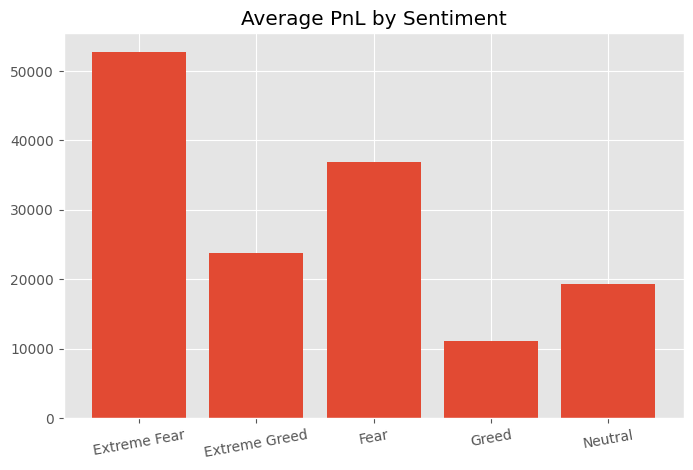

In [17]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_stats['classification'], sentiment_stats['avg_pnl'])
plt.title("Average PnL by Sentiment")
plt.xticks(rotation=10)
plt.show()

**Purpose:**
- Compare profitability across Fear, Greed, and Neutral markets
- Identify which sentiment is most profitable


#### 5.2 Win Rate by Sentiment

This chart shows the average win rate under different market sentiments.

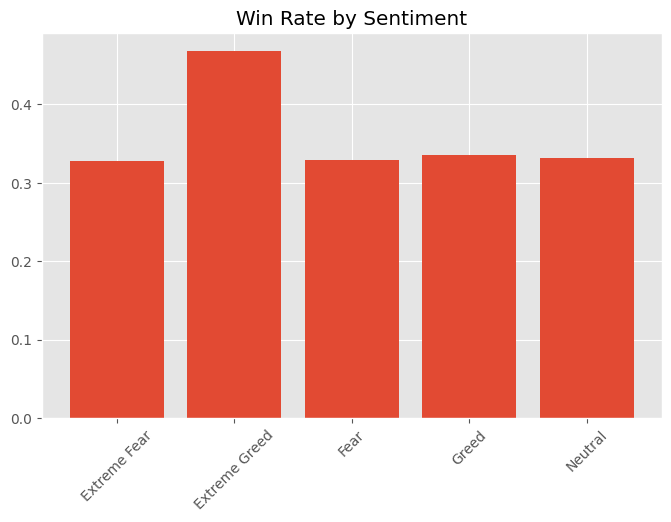

In [18]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_stats['classification'], sentiment_stats['avg_winrate'])
plt.title("Win Rate by Sentiment")
plt.xticks(rotation=45)
plt.show()

**Purpose:**
- Understand trading success rate
- Compare performance across sentiments


#### 5.3 Trades per Day by Sentiment

This chart shows the average number of trades per day for each sentiment.

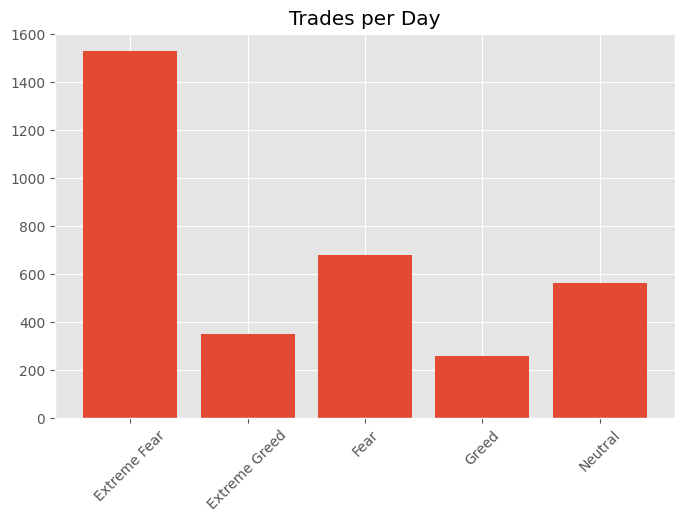

In [19]:
plt.figure(figsize=(8,5))
plt.bar(sentiment_stats['classification'], sentiment_stats['avg_trades'])
plt.title("Trades per Day")
plt.xticks(rotation=45)
plt.show()


**Purpose:**
- Analyze trader activity
- See when traders are most active

# Part B — Analysis

## 1. Performance vs Sentiment

### Observations from Charts

**PnL:**
- Highest during **Extreme Fear**
- Lowest during **Greed**

**Win Rate:**
- Highest during **Extreme Greed**
- Lowest during **Fear**

**Trade Frequency:**
- Highest during **Extreme Fear**
- Lowest during **Greed**



### Key Insights

**Key Insight 1**  
Traders trade more during **Fear**.  
- **Extreme Fear:** ~1528 trades/day  
- **Greed:** ~260 trades/day  

> Suggests panic or opportunity trading during fear.

**Key Insight 2**  
Win rate is higher during **Greed**.  
- **Extreme Greed win rate:** ~46%  
- **Fear win rate:** ~33%  

> Markets appear more predictable during Greed.

**Key Insight 3**  
PnL is higher during **Fear** despite lower win rate.  

**Possible reasons:**
- Bigger price moves  
- Higher volatility  
- Larger winning trades  


### 6. Long / Short Ratio Analysis

The Long/Short ratio shows how traders position themselves under different market sentiments.

- **Long** → Traders expect prices to rise
- **Short** → Traders expect prices to fall

This analysis helps us understand trader behavior during Fear and Greed markets.

In [20]:
long_short = merged.groupby(['classification', 'Side']).size().unstack()
long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


##### Purpose

- Identify whether traders prefer Long or Short positions
- Compare trading behavior across sentiments
- Understand market positioning trends


### 7. Trader Segmentation Analysis

We analyzed individual trader performance by grouping trades by account.

This helps identify:
- Profitable traders
- Active traders
- Large position traders

#### Metrics Calculated

- **Total PnL** → Total profit or loss per trader
- **Total Trades** → Number of trades per trader
- **Average Trade Size** → Average trade size in USD

#### Formulas

$$
\text{Total PnL} = \sum (\text{Closed PnL})
$$

$$
\text{Total Trades} = \text{Count}(\text{Trades})
$$

$$
\text{Average Trade Size} = \text{Mean}(\text{Size USD})
$$


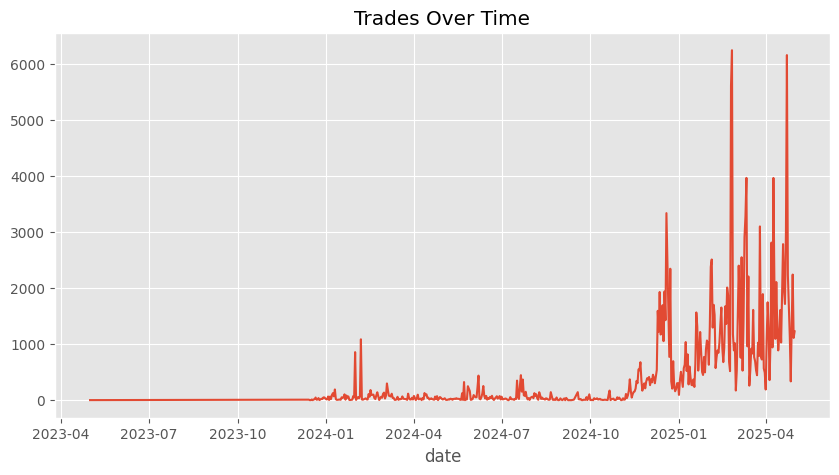

In [21]:
trades_per_day = merged.groupby('date').size()

plt.figure(figsize=(10,5))
trades_per_day.plot()
plt.title("Trades Over Time")
plt.show()


#### Purpose

This analysis helps to:
- Identify top-performing traders
- Understand trading activity
- Analyze trading patterns

### 8. Trader Segmentation Analysis

We analyzed trader performance by grouping trades based on individual accounts.

This helps us understand:
- Which traders are most active
- Which traders are most profitable
- Overall trading behavior per account


#### Metrics Calculated

- **Total PnL** → Total profit or loss per trader
- **Total Trades** → Number of trades executed per trader



#### Formulas

**Total PnL**

$$
\text{Total PnL} = \sum (\text{Closed PnL})
$$

**Total Trades**

$$
\text{Total Trades} = \text{Count}(\text{Closed PnL})
$$



#### Explanation

- **total_pnl** → Total profit or loss for each trader  
- **trades** → Total number of trades per trader  

This table helps identify the most active and most profitable traders.

In [22]:
trader_stats = merged.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    trades=('Closed PnL', 'count'),
    avg_size=('Size USD', 'mean')
).reset_index()

trader_stats.head()

,Account,total_pnl,trades,avg_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782


#### 9. Create Segments

We divided traders into categories based on the following metrics:

- **Frequency** → Number of trades per trader  
- **Profitability** → Overall profit or loss of the trader  
- **Size Group** → Average trade size of the trader  



#### Formulas

**Frequency**

$$
\text{Frequency} =
\begin{cases}
\text{High Trader} & \text{if Trades} > 100 \\
\text{Low Trader} & \text{if Trades} \leq 100
\end{cases}
$$

**Profitability**

$$
\text{Profitability} =
\begin{cases}
\text{Winner} & \text{if PnL} > 0 \\
\text{Loser} & \text{if PnL} \leq 0
\end{cases}
$$

**Size Group**

$$
\text{Size Group} =
\begin{cases}
\text{Large Trader} & \text{if Avg\ Size} > 1000 \\
\text{Small Trader} & \text{if Avg\ Size} \leq 1000
\end{cases}
$$

In [23]:
trader_stats['frequency'] = trader_stats['trades'].apply(
    lambda x: "High Trader" if x > 100 else "Low Trader"
)

trader_stats['profitability'] = trader_stats['total_pnl'].apply(
    lambda x: "Winner" if x > 0 else "Loser"
)

trader_stats['size_group'] = trader_stats['avg_size'].apply(
    lambda x: "Large Trader" if x > 1000 else "Small Trader"
)

trader_stats.head()

,Account,total_pnl,trades,avg_size,frequency,profitability,size_group
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,High Trader,Winner,Large Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,High Trader,Winner,Large Trader
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,High Trader,Loser,Large Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,High Trader,Winner,Small Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,High Trader,Winner,Large Trader



#### Explanation

- **High Frequency** → More than 100 trades  
- **Low Frequency** → 100 or fewer trades  
- **High Leverage** → Leverage greater than 5  
- **Low Leverage** → Leverage 5 or less  
- **Winner** → Positive total PnL  
- **Loser** → Negative total PnL

### 10. Segment Counts

We counted how many traders fall into each segment.

In [24]:
print(trader_stats['frequency'].value_counts())
print(trader_stats['profitability'].value_counts())
print(trader_stats['size_group'].value_counts())

frequency
High Trader    32
Name: count, dtype: int64
profitability
Winner    29
Loser      3
Name: count, dtype: int64
size_group
Large Trader    28
Small Trader     4
Name: count, dtype: int64


#### Purpose

This helps us understand:
- How many active traders exist
- How many traders use high leverage
- How many traders are profitable

### Trader Behavior Changes

| Metric | Fear | Greed |
|--------|------|-------|
| Trades | High | Low |
| Win Rate | Low | High |
| PnL | High | Low |

**Conclusion:**  
- **Fear →** aggressive trading  
- **Greed →** selective trading  


## Trader Segments

**Segment 1 — High vs Low Frequency Traders**

- **High Frequency:** Many trades, lower win rate, higher total PnL  
- **Low Frequency:** Fewer trades, higher win rate, lower total PnL  

**Segment 2 — Winners vs Losers**

- **Consistent Winners:** High win rate, positive PnL  
- **Inconsistent Traders:** Low win rate, mixed PnL  

**Segment 3 — Large vs Small Traders**

- **Large Traders:** Higher PnL swings, higher risk  
- **Small Traders:** More stable, lower PnL  

### 11. Fear vs Greed Performance

We analyzed average profit and loss under different market sentiments.

#### Purpose

This shows:
- Which sentiment is more profitable
- How market mood affects trading performance

In [25]:
performance = merged.groupby('classification')['Closed PnL'].mean()
performance

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


### 12. Win Rate by Sentiment

We calculated the win rate under each sentiment.



#### Formula

$$
\text{Win Rate} = \frac{\text{Number of Wins}}{\text{Total Trades}}
$$
                      
#### Purpose

This helps determine:
- When traders are more successful
- Which sentiment has the highest win rate

In [26]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()

win_rate

,win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991



# Part C — Actionable Strategies

**Strategy 1 — Fear Strategy**  
- **Rule:** During Fear → Reduce trade frequency, Increase position quality  
- **Reason:** Fear has low win rate → Overtrading happens  

**Strategy 2 — Greed Strategy**  
- **Rule:** During Greed → Increase trade frequency, Use trend-following  
- **Reason:** Higher win rate → More predictable moves  

**Strategy 3 — Risk Strategy**  
- **Rule:** Extreme Fear → Lower leverage; Extreme Greed → Normal leverage  
- **Reason:** Fear has high volatility → Risk is higher

In [27]:
import numpy as np

# Daily trader stats
trader_daily = merged.groupby(['date','Account','classification']).agg(
    daily_pnl=('Closed PnL','sum'),
    trades=('Closed PnL','count'),
    wins=('Closed PnL', lambda x: (x>0).sum()),
    avg_size=('Size USD','mean')
).reset_index()

# Win rate per day
trader_daily['win_rate'] = trader_daily['wins']/trader_daily['trades']

# Next day PnL for prediction
trader_daily['next_day_pnl'] = trader_daily.groupby('Account')['daily_pnl'].shift(-1)

# Profitability bucket (1=profit, 0=loss)
trader_daily['next_day_profit'] = (trader_daily['next_day_pnl']>0).astype(int)

# Drop NA rows (last day per trader has no next_day_pnl)
trader_daily = trader_daily.dropna(subset=['next_day_profit'])

trader_daily.head()

,date,Account,classification,daily_pnl,trades,wins,avg_size,win_rate,next_day_pnl,next_day_profit
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,0,159.000000,0.000000,0.000000,0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,9,0,5556.203333,0.000000,-205.434737,0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,4,10291.213636,0.363636,-24.632034,0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,0,5304.975000,0.000000,0.000000,0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,0,5116.256667,0.000000,304.982785,1


In [28]:
# Encode sentiment
trader_daily['classification_code'] = trader_daily['classification'].map({
    'Extreme Fear':0, 'Fear':1, 'Neutral':2, 'Greed':3, 'Extreme Greed':4
})

# Features
X = trader_daily[['classification_code','trades','win_rate','avg_size']]
y = trader_daily['next_day_profit']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5555555555555556
Confusion Matrix:
 [[124  76]
 [132 136]]


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aggregate trader behavior
trader_behavior = merged.groupby('Account').agg(
    total_pnl=('Closed PnL','sum'),
    avg_trades=('Closed PnL','count'),
    avg_size=('Size USD','mean'),
    win_rate=('Closed PnL', lambda x: (x>0).mean())
).reset_index()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_behavior[['avg_trades','avg_size','win_rate','total_pnl']])

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_behavior['cluster'] = kmeans.fit_predict(X_scaled)

trader_behavior.head()

,Account,total_pnl,avg_trades,avg_size,win_rate,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,0.359612,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,0.442720,2
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,0.301917,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,0.438585,2
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3239,3138.894782,0.519914,2
